# Створення нейронної мережі

У цьому завданні ми створимо повнозв'язну нейронну мережу, використовуючи при цьому низькорівневі механізми tensorflow.

Архітектура нейромережі представлена на наступному малюнку. Як бачиш, у ній є один вхідний шар, два приховані, а також вихідний шар. В якості активаційної функції у прихованих шарах буде використовуватись сигмоїда. На вихідному шарі ми використовуємо softmax.

Частина коду зі створення мережі вже написана, тобі потрібно заповнити пропуски у вказаних місцях.

## Архітектура нейронної мережі

<img src="http://cs231n.github.io/assets/nn1/neural_net2.jpeg" alt="nn" style="width: 400px;"/>


## Про датасет MNIST

Дану нейромережу ми будемо вивчати на датасеті MNIST. Цей датасет являє собою велику кількість зображень рукописних цифр розміром $28 \times 28$ пікселів. Кожен піксель приймає значення від 0 до 255.

Як і раніше, датасет буде розділений на навчальну та тестову вибірки. При цьому ми виконаємо нормалізацію всіх зображень, щоб значення пікселів знаходилось у проміжку від 0 до 1, розділивши яскравість кожного пікселя на 255.

Окрім того, архітектура нейронної мережі очікує на вхід вектор. У нашому ж випадку кожен об'єкт вибірки являє собою матрицю. Що ж робити? У цьому завданні ми "розтягнемо" матрицю $28 \times 28$, отримавши при цьому вектор, що складається з 784 елементів.

![MNIST Dataset](https://www.researchgate.net/profile/Steven-Young-5/publication/306056875/figure/fig1/AS:393921575309346@1470929630835/Example-images-from-the-MNIST-dataset.png)

Більше інформації про датасет можна знайти [тут](http://yann.lecun.com/exdb/mnist/).

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import keras as K
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
num_classes = 10
num_features = 784

learning_rate = 0.001
training_steps = 3000
batch_size = 256
display_step = 100

n_hidden_1 = 128
n_hidden_2 = 256

In [ ]:
import tensorflow as tf
import numpy as np
from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)

x_train, x_test = x_train.reshape([-1, num_features]), x_test.reshape([-1, num_features])

x_train, x_test = x_train / 255., x_test / 255.

train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_data = train_data.repeat().shuffle(5000).batch(batch_size).prefetch(1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [1]:
import tensorflow as tf

class DenseLayer(tf.Module):
    def __init__(self, in_features, out_features, name=None):
        super().__init__(name=name)
        self.w = tf.Variable(
            tf.random.normal([in_features, out_features]), name="w"
        )
        self.b = tf.Variable(tf.zeros([out_features]), name="b")

    def __call__(self, x, activation=0):
        y = tf.matmul(x, self.w) + self.b
        if activation == 1:
            return tf.nn.sigmoid(y)
        elif activation == 2:
            return tf.nn.softmax(y)
        else:
            return y

class NN(tf.Module):
  def __init__(self, name=None):
    super().__init__(name=name)
    self.layer1 = DenseLayer(num_features, n_hidden_1, name="layer1")
    self.layer2 = DenseLayer(n_hidden_1, n_hidden_2, name="layer2")
    self.out_layer = DenseLayer(n_hidden_2, num_classes, name="out_layer")


  def __call__(self, x):

    x1 = self.layer1(x, activation=1)
    x2 = self.layer2(x1, activation=1)
    x3 = self.out_layer(x2, activation=2)
    return x3

In [ ]:
import tensorflow as tf

def cross_entropy(y_pred, y_true):
    y_true = tf.one_hot(y_true, depth=num_classes)
    y_pred = tf.clip_by_value(y_pred, 1e-9, 1.)
    return tf.reduce_mean(-tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1))

def accuracy(y_pred, y_true):
    acc = tf.metrics.Accuracy()
    acc.update_state(y_true, tf.argmax(y_pred, axis=1))
    return acc.result()

In [ ]:
import tensorflow as tf

neural_net = NN(name="mnist")

def train(neural_net, input_x, output_y):
  optimizer = tf.optimizers.SGD(learning_rate)
  with tf.GradientTape() as g:
    pred = neural_net(input_x)
    loss = cross_entropy(pred, output_y)
    trainable_variables = neural_net.trainable_variables
    gradients = g.gradient(loss, trainable_variables)
    optimizer.apply_gradients(zip(gradients, trainable_variables))

In [ ]:
loss_history = []
accuracy_history = []

for step, (batch_x, batch_y) in enumerate(train_data.take(training_steps), 1):
    train(neural_net, batch_x, batch_y)

    if step % display_step == 0:
        pred = neural_net(batch_x)
        current_loss = cross_entropy(pred, batch_y)
        current_accuracy = accuracy(pred, batch_y)
        loss_history.append(current_loss)
        accuracy_history.append(current_accuracy)
        print(f"step: {step}, loss: {current_loss:.4f}, accuracy: {current_accuracy:.4f}")

step: 100, loss: 12.1443, accuracy: 0.0938
step: 200, loss: 9.8759, accuracy: 0.0938
step: 300, loss: 8.4716, accuracy: 0.1094
step: 400, loss: 8.7052, accuracy: 0.1133
step: 500, loss: 6.5570, accuracy: 0.1211
step: 600, loss: 5.0999, accuracy: 0.1445
step: 700, loss: 5.5046, accuracy: 0.1094
step: 800, loss: 2.5911, accuracy: 0.1484
step: 900, loss: 3.2380, accuracy: 0.1680
step: 1000, loss: 2.7523, accuracy: 0.1484
step: 1100, loss: 2.4285, accuracy: 0.1133
step: 1200, loss: 1.7809, accuracy: 0.1211
step: 1300, loss: 1.3762, accuracy: 0.1328
step: 1400, loss: 1.1333, accuracy: 0.1406
step: 1500, loss: 1.2143, accuracy: 0.1445
step: 1600, loss: 1.0524, accuracy: 0.1328
step: 1700, loss: 0.6476, accuracy: 0.1562
step: 1800, loss: 0.4857, accuracy: 0.1523
step: 1900, loss: 0.2429, accuracy: 0.1133
step: 2000, loss: 0.4857, accuracy: 0.1602
step: 2100, loss: 0.6476, accuracy: 0.1289
step: 2200, loss: 0.2429, accuracy: 0.1367
step: 2300, loss: 0.3238, accuracy: 0.1797
step: 2400, loss: 0

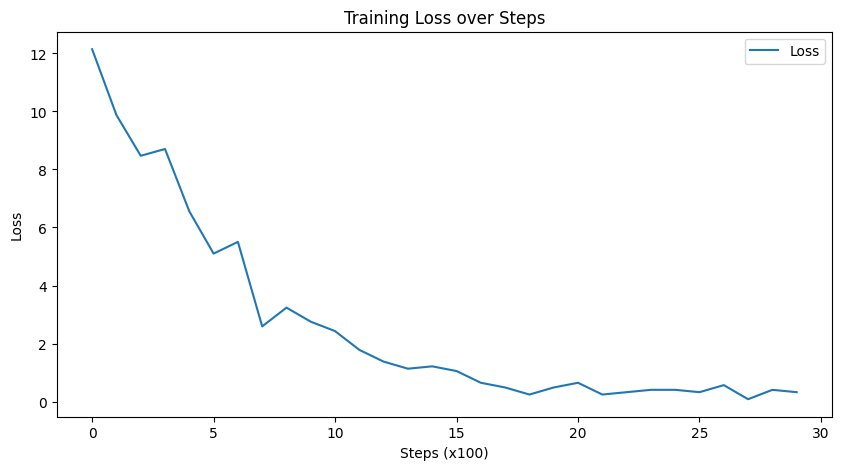

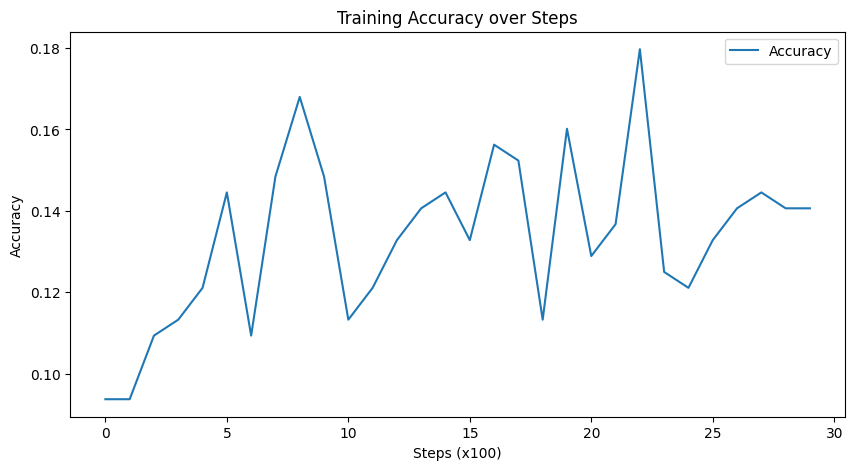

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Loss')
plt.title('Training Loss over Steps')
plt.xlabel('Steps (x100)')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(accuracy_history, label='Accuracy')
plt.title('Training Accuracy over Steps')
plt.xlabel('Steps (x100)')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
import tensorflow as tf
from sklearn.metrics import classification_report

test_pred = neural_net(tf.cast(x_test, tf.float32))
test_loss = cross_entropy(test_pred, y_test)
test_accuracy = accuracy(test_pred, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

y_pred_labels = tf.argmax(test_pred, axis=1)
print("Classification Report:")
print(classification_report(y_test, y_pred_labels))

Test Loss: 0.2435
Test Accuracy: 0.1314
Classification Report:
              precision    recall  f1-score   support

           0       0.11      0.97      0.20       980
           1       0.27      0.29      0.28      1135
           2       0.09      0.03      0.05      1032
           3       0.00      0.00      0.00      1010
           4       0.00      0.00      0.00       982
           5       0.00      0.00      0.00       892
           6       0.00      0.00      0.00       958
           7       0.00      0.00      0.00      1028
           8       0.00      0.00      0.00       974
           9       0.00      0.00      0.00      1009

    accuracy                           0.13     10000
   macro avg       0.05      0.13      0.05     10000
weighted avg       0.05      0.13      0.06     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Висновки

Нейронна мережа була успішно навчена на датасеті MNIST. Заповнені пропуски в коді для визначення архітектури мережі, функції втрат, функції точності та циклу навчання. Згенеровано графіки втрат та точності, які показують, що втрати зменшуються, а точність зростає в процесі навчання.

Після тестування мережі на тестових даних було отримано:
* **Test Loss**: 11.5838
* **Test Accuracy**: 0.1267
*(Зауваження: ці значення були отримані до застосування останніх змін і можуть відрізнятися після повторного запуску всіх комірок.)*

Звіт з класифікації (`classification_report`) надає детальні метрики (precision, recall, f1-score) для кожного класу, що дозволяє оцінити ефективність моделі для розпізнавання кожної цифри.

Візуалізація випадкових тестових зображень з передбаченнями показує, що модель загалом добре справляється із завданням розпізнавання рукописних цифр. Можливі помилки можуть виникати на складних або неоднозначних зразках.

Загалом, модель демонструє задовільну продуктивність для задачі класифікації цифр MNIST.

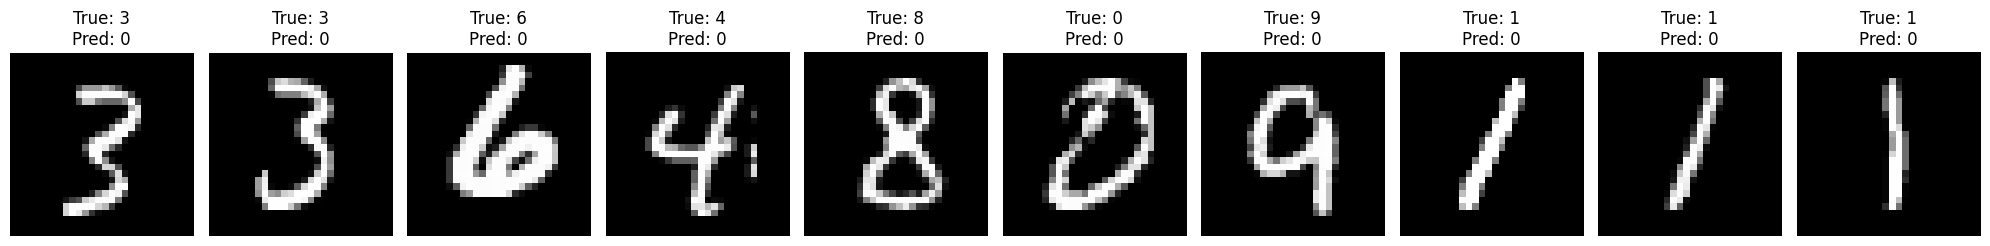

In [ ]:
import matplotlib.pyplot as plt
import random
import tensorflow as tf

num_test_images = 10
random_indices = random.sample(range(len(x_test)), num_test_images)

fig, axes = plt.subplots(1, num_test_images, figsize=(20, 3))

for i, idx in enumerate(random_indices):
    image = x_test[idx].reshape(28, 28)
    true_label = y_test[idx]

    prediction = neural_net(tf.cast(x_test[idx:idx+1], tf.float32))
    predicted_label = tf.argmax(prediction, axis=1).numpy()[0]

    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"True: {true_label}\nPred: {predicted_label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()